<a href="https://colab.research.google.com/github/tomeravgil/Homework6CSCI6170/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets peft accelerate evaluate scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "distilbert-base-uncased"
RANKS = [1, 4, 16, 64]
NUM_EPOCHS = 3
BATCH_SIZE = 32
LEARNING_RATE = 2e-4
MAX_LENGTH = 128

In [ ]:
# Load BoolQ
dataset = load_dataset("google/boolq")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["question"], examples["passage"], truncation=True, max_length=MAX_LENGTH)

tokenized = dataset.map(tokenize_fn, batched=True)

# Convert boolean labels to integers properly
def fix_labels(examples):
    examples["labels"] = [int(b) for b in examples["answer"]]
    return examples

tokenized = tokenized.map(fix_labels, batched=True)
tokenized = tokenized.remove_columns(["answer"])
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_dataset = tokenized["train"]
eval_dataset = tokenized["validation"]
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Train size: {len(train_dataset)}, Eval size: {len(eval_dataset)}")

Map:   0%|          | 0/9427 [00:00<?, ? examples/s]

Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

Map:   0%|          | 0/9427 [00:00<?, ? examples/s]

Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

Train size: 9427, Eval size: 3270


In [ ]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Compute accuracy from Trainer predictions."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)


def count_trainable_params(model):
    """Return (trainable_params, total_params) for a model."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

def make_dora_model(rank):
    """Load a fresh base model and apply DoRA with the given rank."""
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )
    dora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"],
        use_dora=True,
    )
    peft_model = get_peft_model(base_model, dora_config)
    return peft_model

def make_lora_model(rank):
    """Load a fresh base model and apply LoRA with the given rank."""
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=rank,
        lora_alpha=rank * 2,   # common heuristic: alpha = 2 * r
        lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"],  # attention Q and V projections
    )
    peft_model = get_peft_model(base_model, lora_config)
    return peft_model

In [ ]:
results = []

for method_name, model_fn in [("LoRA", make_lora_model), ("DoRA", make_dora_model)]:
    for rank in RANKS:
        print(f"\n{'='*50}")
        print(f"Training {method_name} with rank = {rank}")
        print(f"{'='*50}")

        model = model_fn(rank)
        trainable, total = count_trainable_params(model)
        print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        training_args = TrainingArguments(
            output_dir=f"./{method_name}_rank_{rank}",
            num_train_epochs=NUM_EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            eval_strategy="epoch",
            save_strategy="no",
            learning_rate=LEARNING_RATE,
            weight_decay=0.01,
            logging_steps=50,
            report_to="none",
            seed=42,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        start = time.time()
        trainer.train()
        elapsed = time.time() - start

        eval_result = trainer.evaluate()
        accuracy = eval_result["eval_accuracy"]

        results.append({
            "method": method_name,
            "rank": rank,
            "trainable_params": trainable,
            "total_params": total,
            "pct_trainable": 100 * trainable / total,
            "accuracy": accuracy,
            "time_seconds": elapsed,
        })

        print(f"{method_name} rank {rank} -> Accuracy: {accuracy:.4f}, Time: {elapsed:.1f}s")

        del model, trainer
        import gc, torch
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


Training LoRA with rank = 1


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 610,562 / 67,565,572 (0.90%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.642805,0.640429,0.631193
2,0.609542,0.620120,0.661774
3,0.616022,0.617520,0.662080


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 1,780,994 / 68,736,004 (2.59%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.608600,0.615411,0.671560
2,0.544624,0.592584,0.672783
3,0.539624,0.592115,0.688073


DoRA rank 64 -> Accuracy: 0.6881, Time: 328.4s


  Method   Rank    Trainable  % Total   Accuracy   Time (s)
----------------------------------------------------------
    LoRA      1      610,562    0.90%     0.6621      251.6
    LoRA      4      665,858    0.98%     0.6697      273.6
    LoRA     16      887,042    1.31%     0.6774      274.2
    LoRA     64    1,771,778    2.58%     0.6856      281.0
    DoRA      1      619,778    0.92%     0.6599      317.6
    DoRA      4      675,074    1.00%     0.6685      321.1
    DoRA     16      896,258    1.32%     0.6777      322.4
    DoRA     64    1,780,994    2.59%     0.6881      328.4


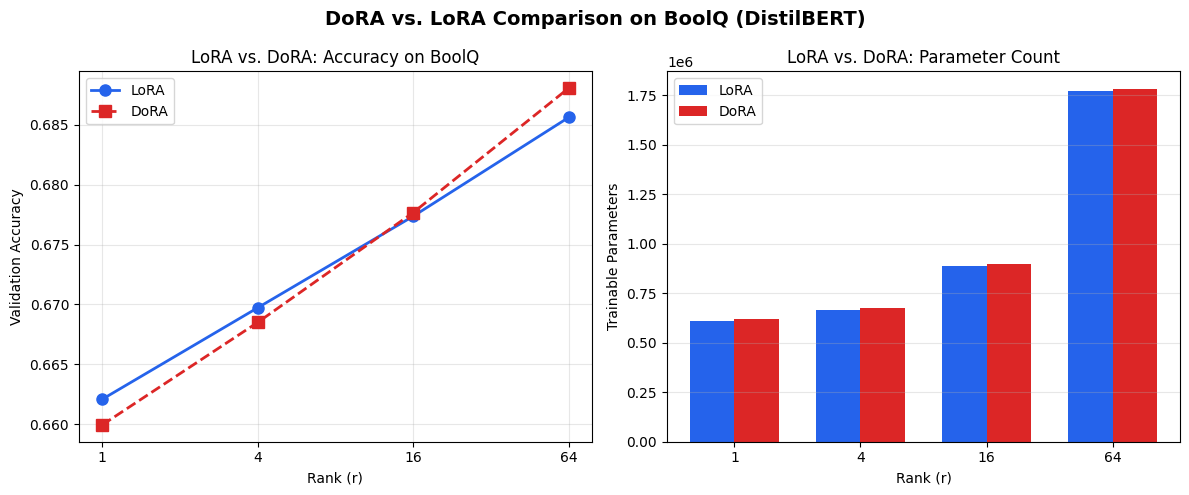

In [ ]:
# Results table
print(f"{'Method':>8} {'Rank':>6} {'Trainable':>12} {'% Total':>8} {'Accuracy':>10} {'Time (s)':>10}")
print("-" * 58)
for r in results:
    print(
        f"{r['method']:>8} "
        f"{r['rank']:>6} "
        f"{r['trainable_params']:>12,} "
        f"{r['pct_trainable']:>7.2f}% "
        f"{r['accuracy']:>10.4f} "
        f"{r['time_seconds']:>10.1f}"
    )

# Split results by method
lora = [r for r in results if r["method"] == "LoRA"]
dora = [r for r in results if r["method"] == "DoRA"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Accuracy comparison
axes[0].plot(RANKS, [r["accuracy"] for r in lora], "o-", color="#2563eb", linewidth=2, markersize=8, label="LoRA")
axes[0].plot(RANKS, [r["accuracy"] for r in dora], "s--", color="#dc2626", linewidth=2, markersize=8, label="DoRA")
axes[0].set_xlabel("Rank (r)")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("LoRA vs. DoRA: Accuracy on BoolQ")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(RANKS)
axes[0].set_xticklabels(RANKS)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Trainable params comparison
x = np.arange(len(RANKS))
w = 0.35
axes[1].bar(x - w/2, [r["trainable_params"] for r in lora], w, color="#2563eb", label="LoRA")
axes[1].bar(x + w/2, [r["trainable_params"] for r in dora], w, color="#dc2626", label="DoRA")
axes[1].set_xlabel("Rank (r)")
axes[1].set_ylabel("Trainable Parameters")
axes[1].set_title("LoRA vs. DoRA: Parameter Count")
axes[1].set_xticks(x)
axes[1].set_xticklabels(RANKS)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("DoRA vs. LoRA Comparison on BoolQ (DistilBERT)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("dora_vs_lora_boolq.png", dpi=150, bbox_inches="tight")
plt.show()